# Imports:

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from category_encoders import BinaryEncoder
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer



# Load the data:

In [2]:
df=pd.read_csv('netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


### general information about the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Null values in each column

In [4]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### the percentage of null values for each column

In [5]:
(df.isna().sum()/8807) *100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

## Data Cleaning

#### convert date_added to pandas datetime type 

In [6]:
df['date_added']=pd.to_datetime(df['date_added'], errors='coerce')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


#### fill null values in director, cast and country columns to be set to 'unknown', and for duration to be 'Not added'

In [8]:
df['director']=df['director'].fillna('unknown')
df['cast']=df['cast'].fillna('unknown')
df['country']=df['country'].fillna('unknown')
df['duration']=df['duration'].fillna('Not added')


In [9]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,unknown,unknown,unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


#### check if your data still has null values

In [10]:
df.isna().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           4
duration         0
listed_in        0
description      0
dtype: int64

#### fill the rest of null values to previous and next values

In [11]:
df = df.ffill().bfill()


In [12]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## Feature Engineering

#### Create features :
* `year_added`, 
* `month_added`,
* `month_name`,
* `duration`: the value in duration column that doesn't contain the word season
* `season_count`: in duration column values that contain the word season

In [13]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.month_name()


In [14]:
def extract_duration_session(arg):
    arg = arg.lower().strip()
    
    duration = 0
    season_count = 0

    if 'min' in arg:
        duration = arg.split(' ')[0]
    
    elif 'season' in arg:
        season_count = arg.split(' ')[0]

    return pd.Series([duration, season_count])

df[['duration_min','season_count']]=df['duration'].apply(extract_duration_session)
        

df


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,duration_min,season_count
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,September,90,0
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,September,0,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,September,0,1
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,September,0,1
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,September,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019,11,November,158,0
8803,s8804,TV Show,Zombie Dumb,unknown,unknown,unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019,7,July,0,2
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019,11,November,88,0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,January,88,0


#### convert all columns to its correct format (e.g.: numeric columns saved as object to float)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8807 non-null   int32         
 13  month_added   8807 non-null   int32         
 14  month_name    8807 non-null   object        
 15  duration_min  8807 non-null   object  

In [16]:
df.isna().sum()     

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
month_name      0
duration_min    0
season_count    0
dtype: int64

In [17]:
df['year_added'] = df['year_added'].astype('Int64')
df['month_added'] = df['month_added'].astype('Int64')
df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce').astype('Int64')
df['season_count'] = pd.to_numeric(df['season_count'], errors='coerce').astype('Int64')





# Data Analysis

#### How many TV-Shows and Movies in this data?

In [25]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [29]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,duration_min,season_count
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,September,90,0
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,September,0,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,September,0,1
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,September,0,1
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,September,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019,11,November,158,0
8803,s8804,TV Show,Zombie Dumb,unknown,unknown,unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019,7,July,0,2
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019,11,November,88,0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,January,88,0


#### How many Horror Movies and Tv Shows on Netflix?

In [27]:
(df['listed_in']=='Horror Movies').sum()

np.int64(55)

In [30]:
(df['listed_in']=='TV Shows').sum()

np.int64(16)

#### What are the top 10 horror movies?

In [34]:
horror_movie=df[(df['listed_in']=='Horror Movies')]

In [36]:
top_10_horror_movie=horror_movie.sort_values(by='release_year', ascending=False).head(10)
top_10_horror_movie

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,duration_min,season_count
307,s308,Movie,Aftermath,Peter Winther,"Ashley Greene, Shawn Ashmore, Sharif Atkins, B...",United States,2021-08-04,2021,TV-MA,115 min,Horror Movies,"Desperate to save their marriage, a young coup...",2021,8,August,115,0
643,s644,Movie,The Seventh Day,Justin P. Lange,"Guy Pearce, Vadhir Derbez, Stephen Lang, Brady...",United States,2021-06-24,2021,R,87 min,Horror Movies,An inexperienced priest teams up with a harden...,2021,6,June,87,0
479,s480,Movie,Fear Street Part 2: 1978,Leigh Janiak,"Sadie Sink, Emily Rudd, Ryan Simpkins, McCabe ...",unknown,2021-07-09,2021,R,111 min,Horror Movies,"In the cursed town of Shadyside, a killer's mu...",2021,7,July,111,0
728,s729,Movie,The Devil Below,Bradley Parker,"Alicia Sanz, Will Patton, Jonathan Sadowski, A...",United States,2021-06-13,2021,TV-MA,89 min,Horror Movies,When a team of researchers tries to find out w...,2021,6,June,89,0
229,s230,Movie,The Old Ways,Christopher Alender,"Brigitte Kali Canales, Andrea Cortes, Julia Ve...",United States,2021-08-25,2020,TV-MA,90 min,Horror Movies,A reporter visits her birthplace in Veracruz f...,2021,8,August,90,0
1398,s1399,Movie,Death of Me,Darren Lynn Bousman,"Maggie Q, Luke Hemsworth, Alex Essoe, Ingkarat...","United States, Thailand",2021-01-16,2020,R,94 min,Horror Movies,"With no memory of the previous night, a vacati...",2021,1,January,94,0
1648,s1649,Movie,Ghosts of War,Eric Bress,"Brenton Thwaites, Theo Rossi, Skylar Astin, Ky...",United Kingdom,2020-11-25,2020,R,95 min,Horror Movies,"Five, battle-worn Allied soldiers guarding a c...",2020,11,November,95,0
3398,s3399,Movie,Eli,Ciarán Foy,"Charlie Shotwell, Lili Taylor, Kelly Reilly, M...",United States,2019-10-18,2019,TV-MA,98 min,Horror Movies,"With his desperate parents in tow, an 11-year-...",2019,10,October,98,0
3014,s3015,Movie,Deadcon,Caryn Waechter,"Lauren Elizabeth, Claudia Sulewski, Keith Mach...",United States,2020-01-16,2019,TV-14,78 min,Horror Movies,"A group of uber-popular, social media influenc...",2020,1,January,78,0
822,s823,Movie,The Wind,Emma Tammi,"Caitlin Gerard, Julia Goldani Telles, Ashley Z...",United States,2021-06-02,2019,R,88 min,Horror Movies,Isolated on a wind-ravaged 19th-century homest...,2021,6,June,88,0


#### What is the average duration of the movie?

In [43]:
movie_type=df[(df['type']=='Movie')]

In [49]:
movie_type['duration_min'].mean()

np.float64(99.52846191485891)

#### Create a summary statstics table for duration and season count features using dedicated pandas function

In [50]:
df[['duration_min', 'season_count']].describe()

,duration_min,season_count
count,8807.0,8807.0
mean,69.286817,0.536278
std,51.534755,1.19162
min,0.0,0.0
25%,0.0,0.0
50%,88.0,0.0
75%,106.0,1.0
max,312.0,17.0


#### longest movie ever

In [ ]:
movie_type.sort_values(by='duration_min', ascending=False).head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,duration_min,season_count
4253,s4254,Movie,Black Mirror: Bandersnatch,unknown,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,2018-12-28,2018,TV-MA,312 min,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",2018,12,December,312,0


#### top 10 countries in Movie releases

In [57]:
top_countries = movie_type.groupby('country')['title'].count().sort_values(ascending=False).head(10)
top_countries


country
United States     2058
India              893
unknown            440
United Kingdom     206
Canada             122
Spain               97
Egypt               92
Nigeria             86
Indonesia           77
Turkey              76
Name: title, dtype: int64

#### top 10 countries in Tv-Show releases 

In [60]:
top_countries = df[(df['type']=='TV Show')].groupby('country')['title'].count().sort_values(ascending=False).head(10)
top_countries


country
United States     760
unknown           391
United Kingdom    213
Japan             169
South Korea       158
India              79
Taiwan             68
Canada             59
France             49
Australia          48
Name: title, dtype: int64

#### How many movies released in 2018 for each category?

In [71]:
movies_2018=movie_type[movie_type['release_year']==2018]
movies_2018
movies_2018.groupby('listed_in')['title'].count()


listed_in
Action & Adventure                                                  12
Action & Adventure, Anime Features, Children & Family Movies         1
Action & Adventure, Anime Features, International Movies             3
Action & Adventure, Children & Family Movies, Dramas                 1
Action & Adventure, Children & Family Movies, Independent Movies     1
                                                                    ..
Romantic Movies                                                      2
Sci-Fi & Fantasy                                                     1
Sci-Fi & Fantasy, Thrillers                                          5
Stand-Up Comedy                                                     58
Thrillers                                                            8
Name: title, Length: 127, dtype: int64

#### What are movies for Tom Cruise?

In [105]:
tom_cruise_movies = movie_type[movie_type['cast'].str.contains('Tom Cruise')]
tom_cruise_movies


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,duration_min,season_count
341,s342,Movie,Magnolia,Paul Thomas Anderson,"John C. Reilly, Philip Baker Hall, Tom Cruise,...",United States,2021-08-01,1999,R,189 min,"Dramas, Independent Movies","Through chance, history and divine interventio...",2021,8,August,189,0
1254,s1255,Movie,Rain Man,Barry Levinson,"Dustin Hoffman, Tom Cruise, Valeria Golino, Ge...",United States,2021-03-01,1988,R,134 min,"Classic Movies, Dramas","Motivated by money, a selfish workaholic seeki...",2021,3,March,134,0


False

# Visualizations

#### Content Type on Netflix

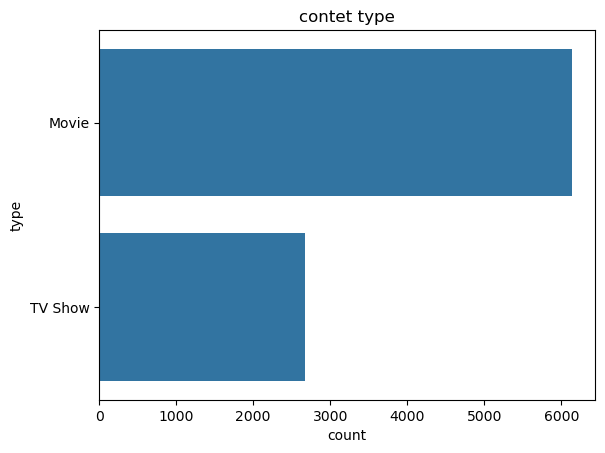

In [110]:
sns.countplot(df['type'])
plt.title('contet type')
plt.show()

#### Growth in content over the months AND over the years

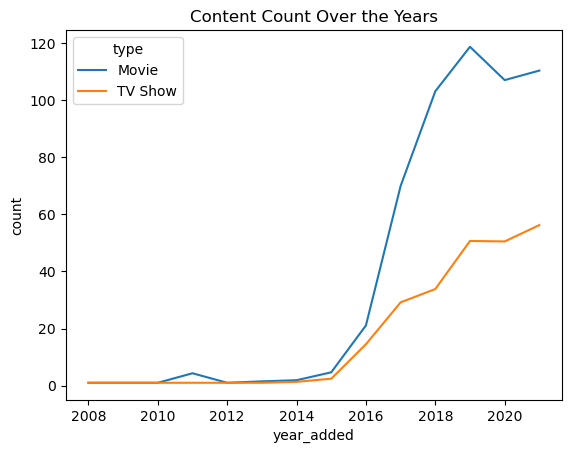

In [149]:
dff=df.groupby(['type','year_added','month_added'])['title'].count().reset_index(name='count')
sns.lineplot(data=dff, x='year_added', y='count',hue='type',errorbar=None)
plt.title('Content Count Over the Years')
plt.show()


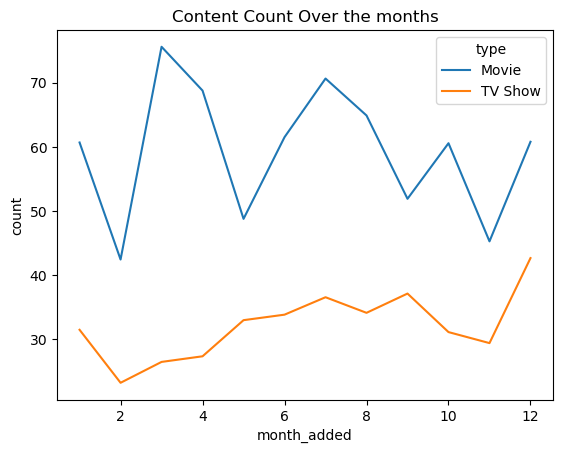

In [152]:
sns.lineplot(data=dff, x='month_added', y='count',hue='type',errorbar=None)
plt.title('Content Count Over the months')
plt.show()


In [151]:
dff

,type,year_added,month_added,count
0,Movie,2008,1,1
1,Movie,2009,5,1
2,Movie,2009,11,1
3,Movie,2010,11,1
4,Movie,2011,5,1
...,...,...,...,...
184,TV Show,2021,5,38
185,TV Show,2021,6,83
186,TV Show,2021,7,88
187,TV Show,2021,8,61


#### The ratings of the content

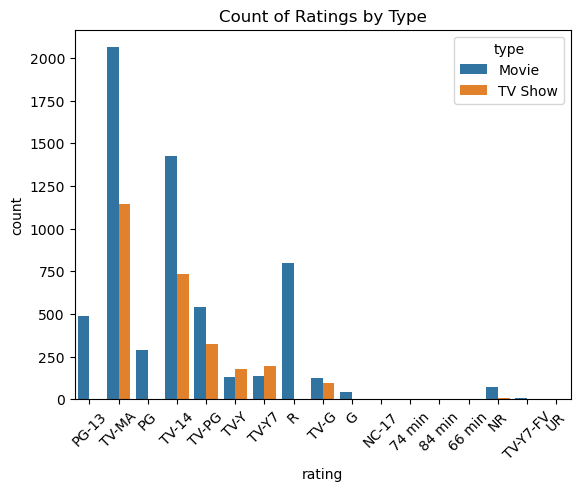

In [155]:
sns.countplot(data=df, x='rating', hue='type')
plt.title("Count of Ratings by Type")
plt.xticks(rotation=45)
plt.show()


#### What are the top Categories?

In [160]:
top_categories = df['listed_in'].value_counts().head(10)
top_categories
px.bar(top_categories,title='Top 10 Content Categories')
